# Time Series Analysis
* Time Series Data Structures
* Time Series Patterns
* Time Series Components
* Time Series Regression: Model as a Reasonable Approximation of Reality
* Simple Forecasting Methods
    - Average Method
    - Naive Method
    - Seasonal Naive Method
    - Drift Method


## Time Series Data Structures


**In the example:**
- A time-indexed DataFrame is created.
- A rolling mean is calculated to smooth the series.
- The original data and its rolling mean are plotted.

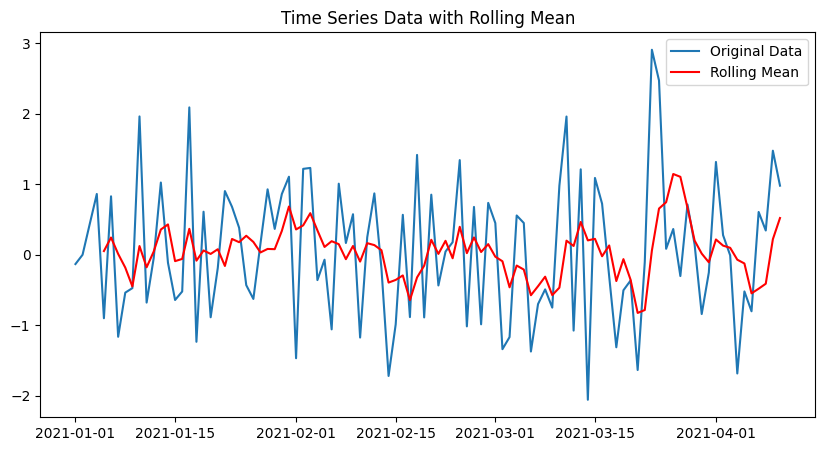

In [1]:
import pandas as pd
import numpy as np

# Create a date range
date_range = pd.date_range(start='2021-01-01', periods=100, freq='D')

# Generate some synthetic data
data = np.random.randn(100)

# Create a DataFrame with a time index
time_series = pd.DataFrame(data, index=date_range, columns=['Value'])

# Basic manipulation: Rolling mean
rolling_mean = time_series.rolling(window=5).mean()

# Plotting the time series and rolling mean
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(time_series, label='Original Data')
plt.plot(rolling_mean, label='Rolling Mean', color='red')
plt.title('Time Series Data with Rolling Mean')
plt.legend()
plt.show()

## Time Series Patterns
Slides are from my lecture slides

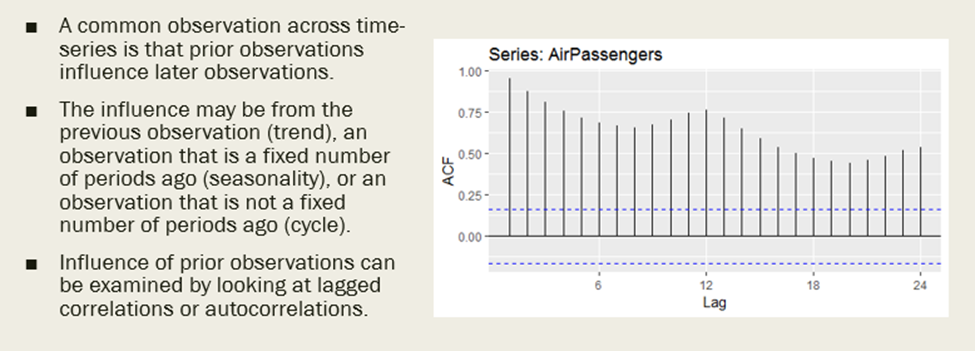

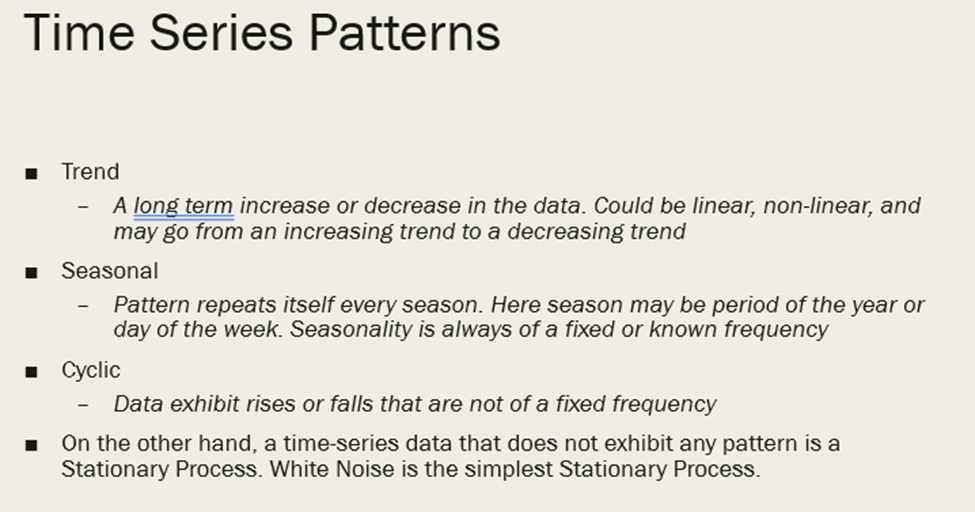

The concept that **prior observations influence later observations in time series analysis** refers to the ***dependency that past values of a series can have on its future values***. This is ***a foundational aspect of time series analysis***, which differentiates it from other types of data analysis where observations are generally assumed to be independent.

**Explanation of Concepts**
- Trend: A long term increase or decrease in the data. Could be linear, non-linear, and may go from an increasing trend to a decreasing trend.
    * This influence could be because of a trend in the data. For example, if a company's sales have been increasing over the last few quarters, this trend might suggest that future sales will also be higher. Trends can be upward or downward and are about the direction in which the series is moving over time.
- Seasonality: Pattern repeats itself every season, Here season may be period of the year or day of the week. Seasonality is always of a fixed or known frequency.
    * Seasonal influences occur when observations are affected by seasonal factors. For example, airline passenger traffic typically increases during certain times of the year like holidays or summer vacation seasons. So, the number of air passengers in July (a peak travel month) is likely influenced by the fact that it is part of the summer season, not necessarily by the number of passengers in June.
- Cyclic (Cycle): Data exhibit rises or falls that are not of a fixed frequency.
    * Cycles are fluctuations that occur due to non-seasonal reasons and are not of a fixed period. For example, business cycles which affect the overall economic activity can cause cyclical fluctuations in a company’s sales data.
- Stationary Process: A time-series data that does not exhibit any pattern is a stationary process. White Noise is the simplest stationary process

**Autocorrelations and Lagged Correlations**
* Autocorrelation: Autocorrelation measures the relationship between a variable's current value and its past values. A significant autocorrelation indicates that the data points are not independent of each other. 
    * The autocorrelation function (ACF) plot in the slide shows how the air passengers data correlates with itself at different lags.

* Calculation of Autocorrelation

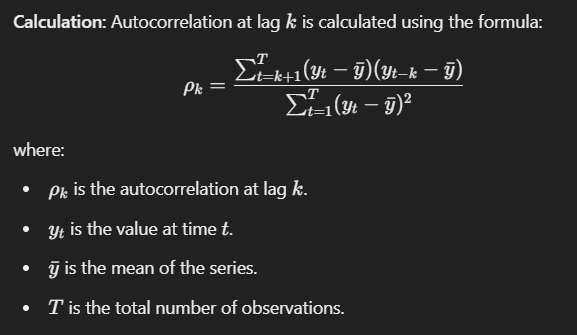

* Lagged Correlation: Lagged correlation is similar to autocorrelation but typically refers to the correlation between two different time series at various lags. This can help in understanding the lead-lag relationships between different economic, financial, or environmental variables. One example might be "Researchers might explore how changes in carbon emissions correlate with changes in average temperature or weather patterns, where effects may not be immediate but occur over various lag times".


* Calculation of Lagged Correlation

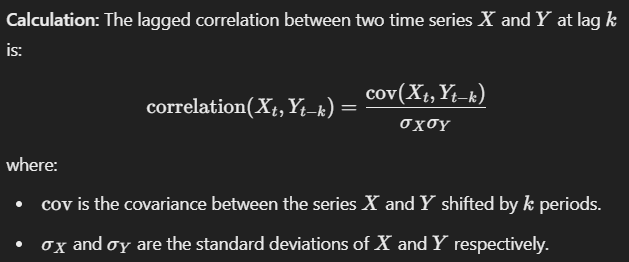

* Distinction of the Two
- Autocorrelation specifically refers to the correlation of a single time series with its own past and future values. It examines how well the current value of a series is related to its past (or future) values, which is a key feature in time series analysis, particularly for identifying patterns like seasonality and trends within a single dataset.
- Lagged Correlation, on the other hand, generally involves comparing two different time series at various lags. For example, it could be used to determine if there’s a relationship between advertising spend in one month and sales revenue in subsequent months, where each series is distinct but related over time.
- So, while both concepts deal with time shifts ("lags"), autocorrelation is an intra-series analysis (within the same series), and lagged correlation is an inter-series analysis (between two different series).

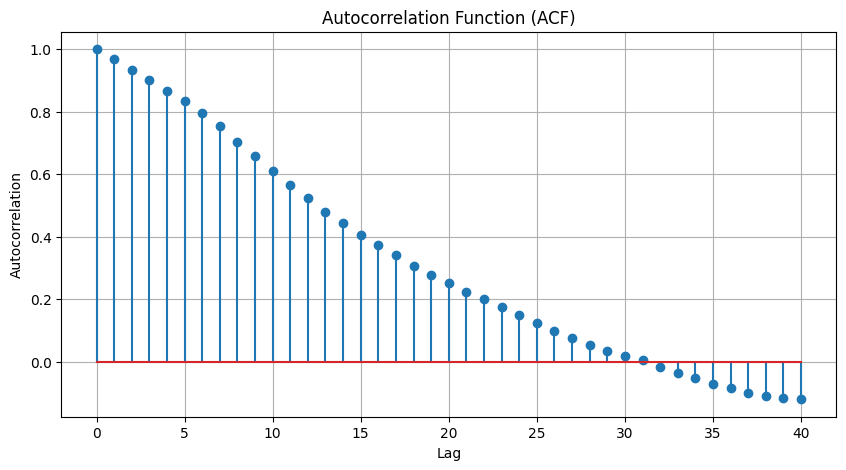

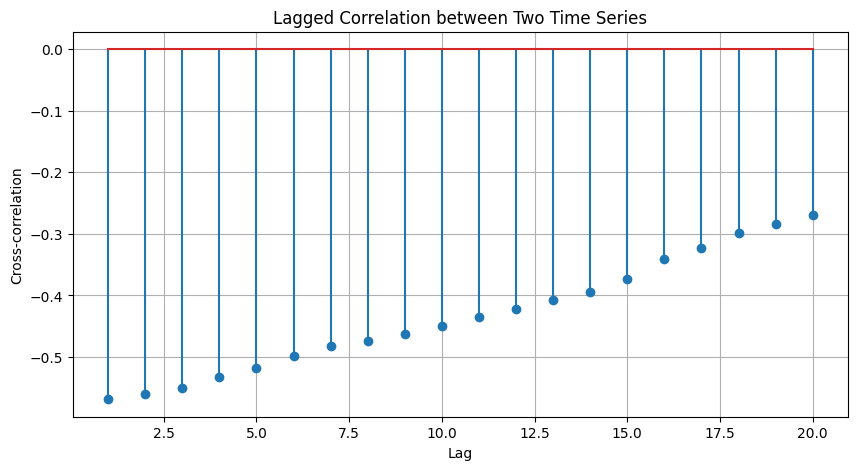

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Generating synthetic time series data
np.random.seed(42)
n_points = 120
time_series = np.cumsum(np.random.randn(n_points))  # Cumulative sum to introduce autocorrelation

# Calculate autocorrelation using statsmodels
from statsmodels.tsa.stattools import acf
autocorrelations = acf(time_series, nlags=40, fft=False)

# Plotting the autocorrelations
plt.figure(figsize=(10, 5))
plt.stem(range(len(autocorrelations)), autocorrelations)  # Removed use_line_collection=True
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF)')
plt.grid(True)
plt.show()

# Generating another time series for lagged correlation
time_series2 = np.cumsum(np.random.randn(n_points))

# Calculating cross-correlation
cross_correlations = [np.corrcoef(time_series[i:], time_series2[:-i])[0, 1] if i != 0 else np.corrcoef(time_series, time_series2)[0, 1] for i in range(1, 21)]

# Plotting cross-correlations
plt.figure(figsize=(10, 5))
plt.stem(range(1, 21), cross_correlations)  # Removed use_line_collection=True
plt.xlabel('Lag')
plt.ylabel('Cross-correlation')
plt.title('Lagged Correlation between Two Time Series')
plt.grid(True)
plt.show()

## Time Series Components

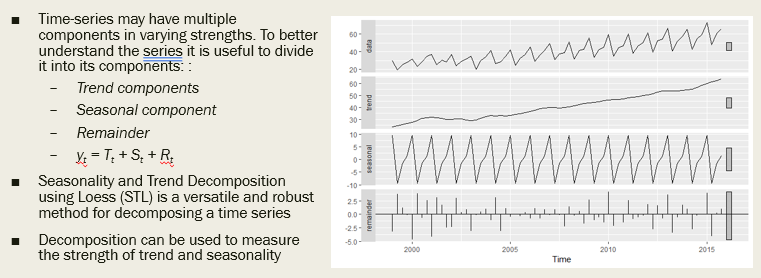

**Underlying Theory**
STL Decomposition separates a time series into three components:
1. Trend (T): Reflects the long-term progression of the series (e.g., increasing, decreasing). It does not have to be linear.
2. Seasonal (S): Reflects the seasonality (repeating short-term cycle) within the data.
3. Residual (R): The remainder of the time series after the trend and seasonal components have been removed; it is sometimes referred to as the irregular component.

**Components**
* Trend component (T) captures the gradual changes over time.
* Seasonal component (S) captures patterns that repeat over a known period, such as daily, monthly, or quarterly.
* Residual component (R) captures the irregularities or 'noise' that cannot be explained by the trend or seasonal components.

**Calculation with LOESS/STL**

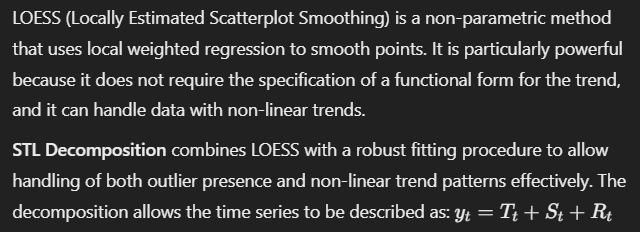

**Window Length**
- What it Means for Data to Conform Tightly to the Trend or Seasonal Components:
    * When we say that the data conforms "tightly" to the trend or seasonal components, we're talking about ***how closely the smoothed line (or curve) follows the actual ups and downs of the data***. A "tight" fit means the smoothed line will closely trace these fluctuations, rather than smoothing them out into a more gentle, less variable curve.

- Effect of Smaller vs. Larger Window Lengths:
    * **Smaller Window Lengths**: This means that each calculation of the trend or seasonal component at a point in time considers only a small number of nearby data points. As a result, the ***smoothing is more sensitive to local variations in the data***. This can be useful for detecting and following rapid changes in the data, like sudden increases in sales or seasonal peaks.
- **Larger Window Lengths**: Here, each calculation considers a larger number of data points, which averages out more of the short-term fluctuations and ***focuses on longer-term patterns***. This is useful for identifying more stable, underlying trends in the data, like gradual increases or decreases over several years.

- Neighborhood Used to Perform Local Regression
    * The "neighborhood" refers to the subset of data points used at each step of the smoothing process. The size of this neighborhood is directly controlled by the window length:
    * Span or Size of the Neighborhood: This is essentially the range of data points around each target point that LOESS uses to fit a local regression model. If you imagine smoothing a point in the middle of your time series, the neighborhood is the group of points around it — both before and after — that are included in the fit.
    * The span or size influences how much of the local data's "context" or "environment" is considered when calculating the smooth curve at that point. ***A larger neighborhood integrates a broader context, leading to a smoother overall curve because it "dilutes" any single point's influence***. ***A smaller neighborhood gives more weight to the immediate vicinity, allowing for a more responsive fit that can adapt quickly to changes in the data pattern***.

**Example to Illustrate:**
- Imagine you're analyzing monthly sales data with some months seeing sudden spikes due to promotional events. If you use a small window length, your seasonal component in STL might closely follow these spikes, indicating a high impact of promotions. In contrast, a larger window might smooth out these spikes, highlighting steadier, underlying seasonal patterns that aren't as affected by one-time events.

- By choosing the window length, you control this balance between responsiveness to immediate changes and the stability of broader trends, which is crucial depending on your specific analytical needs and the nature of the data you are studying.

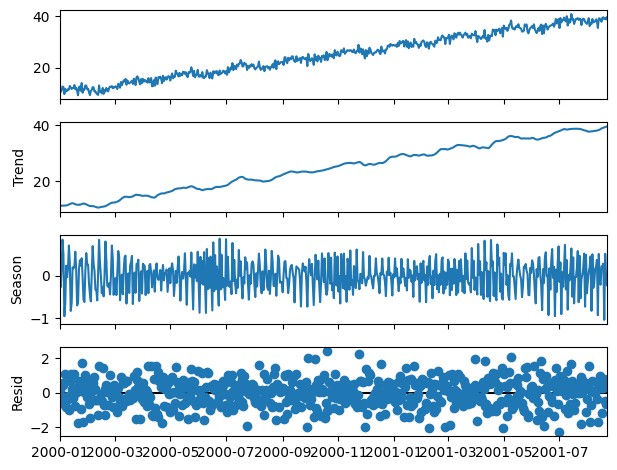

In [5]:
# Code example of using STL decomposition for time series components
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Generate synthetic time series data
np.random.seed(0)
n_points = 600
t = np.arange(n_points)
data = 10 + 0.05 * t + np.sin(t * 2 * np.pi / 60) + np.random.normal(size=n_points)

# Convert to pandas DataFrame for STL
ts = pd.Series(data, index=pd.date_range(start='2000-01-01', periods=n_points, freq='D'))

# Apply STL decomposition
stl = STL(ts, seasonal=13)
result = stl.fit()

# Plot the decomposed components
result.plot()
plt.show()

## Time Series Regression: Model as a Reasonable Approximation of Reality
- The regression model should logically reflect the underlying process being studied. The model's form (linear, non-linear, etc.) and the variables included should make sense given the data's context and the relationships you expect to find based on domain knowledge or previous findings.

**Assumptions About the Errors**
The regression model's residuals (errors) are the differences between the observed values and the values predicted by the model. For the model to be valid, these errors must meet several criteria:
1. Mean of 0: This means that the residuals, on average, should be zero. If the mean of the residuals is not zero, it indicates a bias in the model, suggesting that the model consistently overestimates or underestimates the observed values.

2. Not Auto-correlated: ***Autocorrelation in residuals means that errors are correlated with each other across time lags***. This would suggest that some pattern in the time series is not captured by the model, which could be due to missing variables, wrong model specification, or other reasons.

3. Unrelated to Predictors: ***The residuals should not show any pattern or correlation with the independent variables (predictors)***. If such a correlation exists, it indicates that the model has not fully captured the relationship between the predictors and the dependent variable, possibly due to model misspecification.

**Distribution of Errors**
For many statistical tests and confidence intervals to be valid, the residuals must also satisfy these conditions:
1. Normally Distributed: If the residuals are normally distributed, it supports the use of various statistical measures and tests that assume normality. This assumption is crucial for deriving reliable hypothesis tests and confidence intervals.

2. Constant Variance (Homoscedasticity): The residuals should have constant variance. If the variance changes over time or across levels of an independent variable, the condition known as heteroscedasticity occurs. This can lead to inefficient estimates and affect the reliability of some statistical tests, leading to misleading inferences.

**Practical Implementation**
- To check these assumptions in Python, you can use statistical plots and tests:
    * Plotting residuals can help visualize if they have a mean of zero and constant variance.
    * Autocorrelation can be checked using plots like the Autocorrelation Function (ACF) plot.
Normality can be tested using statistical tests like the Shapiro-Wilk test.

Mean of residuals: -3.2862601528904633e-16


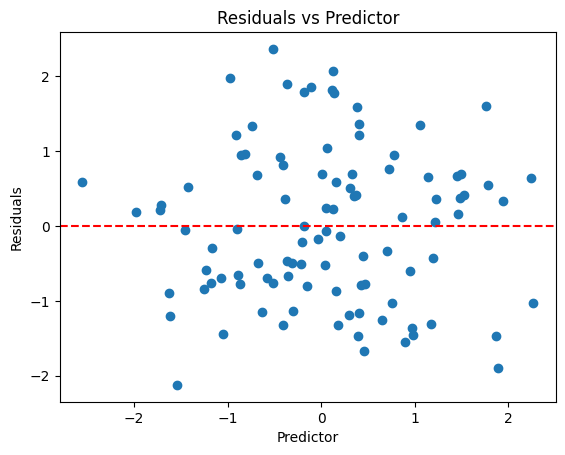

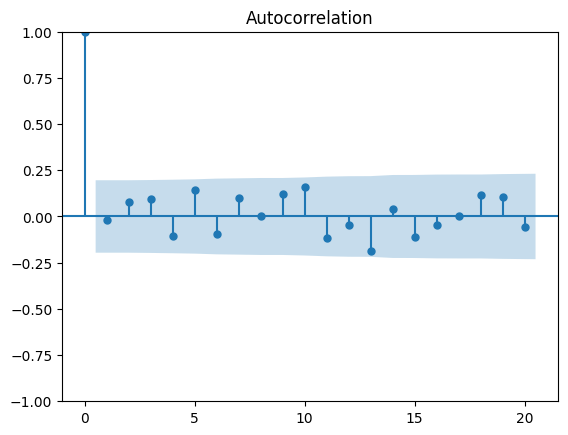

In [6]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
x = np.random.normal(0, 1, 100)
y = 2*x + np.random.normal(0, 1, 100)  # y is a function of x plus some noise

# Fit a simple linear regression model
model = sm.OLS(y, sm.add_constant(x)).fit()

# Check for mean of residuals
print("Mean of residuals:", np.mean(model.resid))

# Plot residuals to check for constant variance and no correlation with predictors
plt.scatter(x, model.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predictor')
plt.ylabel('Residuals')
plt.title('Residuals vs Predictor')
plt.show()

# Check for autocorrelation of residuals
sm.graphics.tsa.plot_acf(model.resid)
plt.show()

## Simple Forecasting Methods
 - Average Method
 - Naive Method
 - Seasonal Naive Method
 - Drift Method
 - Use the TSL Decomposition to break down the prediction into treand and seasonality

### Average Method
**Underlying Theory**
- This method forecasts future values by simply taking the average of all past data points. It assumes that all historical observations are equally important and there are no trends or seasonal variations influencing the data.
- A very simple prediction, often the baseline in linear regression, is to use the average

**Calculation**

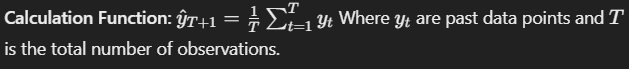

C:\Users\Michael\AppData\Local\Temp\ipykernel_42020\766202428.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2000-01-01', periods=len(data), freq='M')
C:\Users\Michael\AppData\Local\Temp\ipykernel_42020\766202428.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=dates[-1], periods=n_forecast + 1, freq='M')[1:]


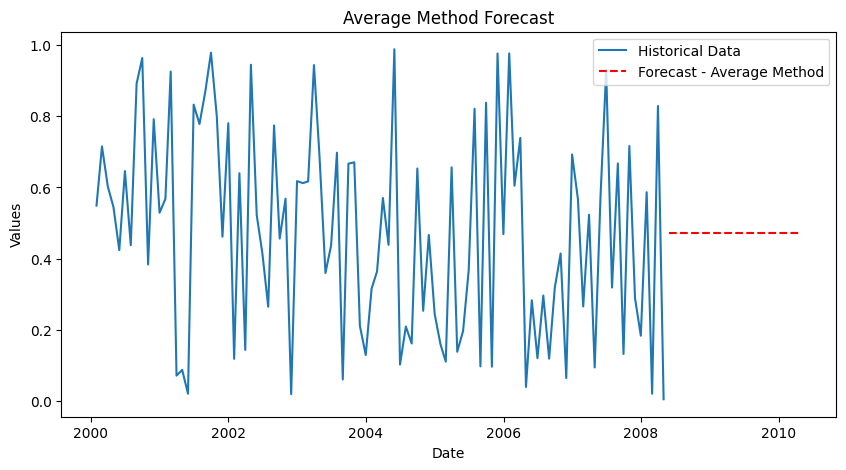

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Generating synthetic data
np.random.seed(0)
data = np.random.rand(100)  # 100 random data points
dates = pd.date_range(start='2000-01-01', periods=len(data), freq='M')

# Calculate the average
forecast_average = np.mean(data)

# Extend the forecast into the future
n_forecast = 24  # forecasting for 24 periods
future_dates = pd.date_range(start=dates[-1], periods=n_forecast + 1, freq='M')[1:]
forecast_values = np.full(shape=(n_forecast,), fill_value=forecast_average)

# Plotting the historical data and the forecast
plt.figure(figsize=(10, 5))
plt.plot(dates, data, label='Historical Data')
plt.plot(future_dates, forecast_values, 'r--', label='Forecast - Average Method')
plt.legend()
plt.title('Average Method Forecast')
plt.xlabel('Date')
plt.ylabel('Values')
plt.show()

### Naive Method
**Underlying Theory**
- The naïve method assumes that the next value will be the same as the last observed value. This is particularly useful for series that are relatively stable or when data shows randomness (like a random walk).
- Future will be the same as the last observation
- Since this is the best prediction for a random walk, these are also called random walk forecasts

**Calculation**

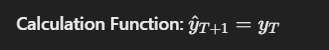

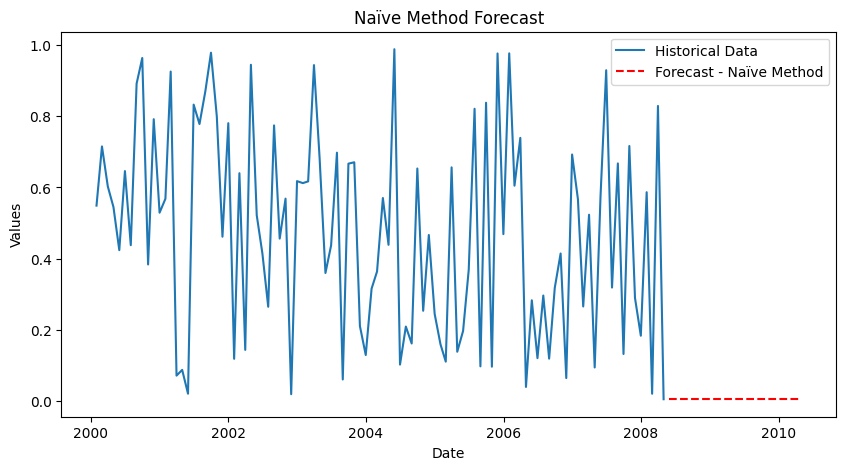

In [10]:
# Naive forecast
forecast_naive = data[-1]

# Forecasting future values as the last observed value
naive_values = np.full(shape=(n_forecast,), fill_value=forecast_naive)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(dates, data, label='Historical Data')
plt.plot(future_dates, naive_values, 'r--', label='Forecast - Naïve Method')
plt.legend()
plt.title('Naïve Method Forecast')
plt.xlabel('Date')
plt.ylabel('Values')
plt.show()

### Seasonal Naive Method
**Underlying Theory**
- This approach uses the last observed value from the same season or cycle in the past data. It's effective when the data exhibits strong seasonal patterns.

**Calculation**

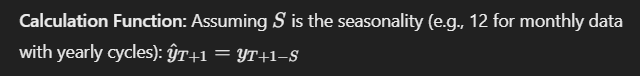

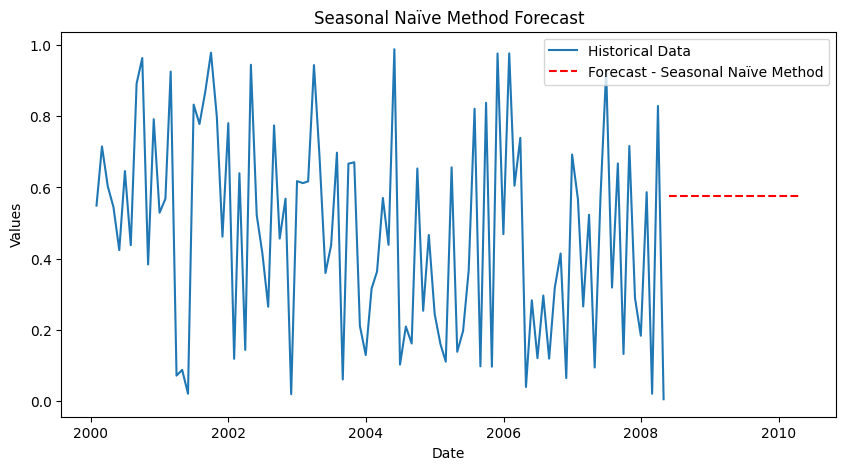

In [11]:
# Seasonal Naïve forecast
seasonality = 12
forecast_seasonal_naive = data[-seasonality]

# Repeat the last observed seasonal value
seasonal_naive_values = np.tile(forecast_seasonal_naive, n_forecast)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(dates, data, label='Historical Data')
plt.plot(future_dates, seasonal_naive_values, 'r--', label='Forecast - Seasonal Naïve Method')
plt.legend()
plt.title('Seasonal Naïve Method Forecast')
plt.xlabel('Date')
plt.ylabel('Values')
plt.show()

### Drift Method
**Underlying Theory**
- The drift method allows the forecasts to change over time, incorporating a trend component that reflects how the changes between data points have moved over time. It linearly extrapolates the changes observed in the historical data.
- Allow forecasts to increase or decrease over time, where the amount of change over time (called the drift) is set to be average change seen in historical data

**Calculation**

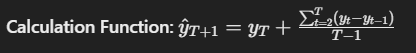

**Example**
- Example Explanation
    * Let's assume you have monthly sales data over a year (12 months), and you're trying to forecast the next month's sales using the drift method. Here are the hypothetical last two months' sales:
        - November: 200 units
        - December: 210 units
    * Here, we see an increase of 10 units from November to December. The drift is simply this change, which we then project forward as a constant change for the future periods.

- Calculation
    * Drift Calculation:
        * Drift = December Sales - November Sales = 210 - 200 = 10 units
    * Assuming you want to forecast for the next three months (January, February, March), you would add the drift to the last observed value for each subsequent period.

- Forecast:
    * January: Last observed value (December) + Drift = 210 + 10 = 220 units
    * February: January forecast + Drift = 220 + 10 = 230 units
    * March: February forecast + Drift = 230 + 10 = 240 units

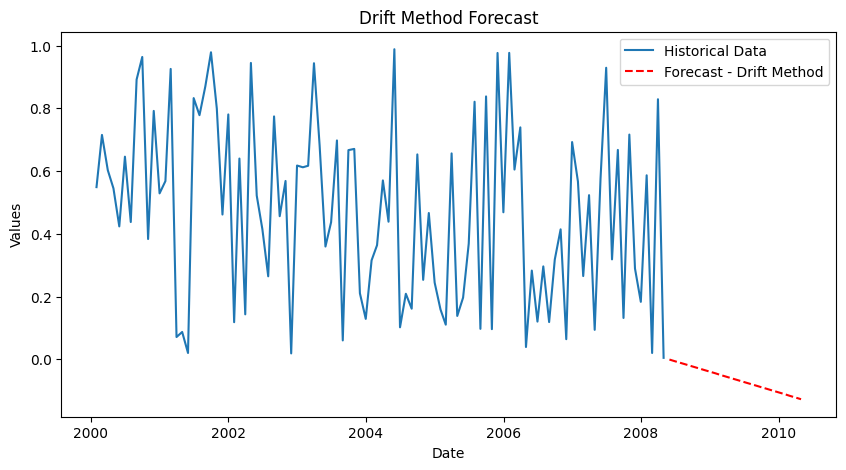

In [12]:
# Drift calculation
drift = (data[-1] - data[0]) / (len(data) - 1)
forecast_drift = np.array([data[-1] + drift * i for i in range(1, n_forecast + 1)])

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(dates, data, label='Historical Data')
plt.plot(future_dates, forecast_drift, 'r--', label='Forecast - Drift Method')
plt.legend()
plt.title('Drift Method Forecast')
plt.xlabel('Date')
plt.ylabel('Values')
plt.show()

### Use the TSL Decomposition to break down the prediction into treand and seasonality

**Example Data and Decomposition**
- Assume you have monthly sales data for an entire year that exhibits both a linear trend and a seasonal pattern. We'll use STL to decompose this data.

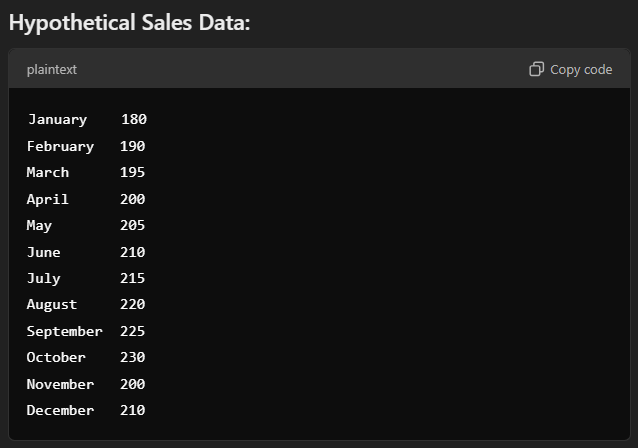

**Explanation:**
* Decomposition: The STL decomposition method is applied to the sales data to separate it into trend, seasonal, and residual components. STL is flexible and robust, making it suitable for handling any irregularities in the data.
* Trend Forecasting: The trend component is forecasted using the slope of the last two points. This assumes that the trend will continue at the same rate.
* Seasonal Forecasting: The seasonal component is assumed to be consistent on a yearly basis. The forecast for the seasonal component uses the last known seasonal values for the same months.
* Total Forecast: The total forecast is the sum of the trend and seasonal forecasts. This approach allows the forecast to account for both the ongoing trend and the seasonal fluctuations observed in the historical data.

C:\Users\Michael\AppData\Local\Temp\ipykernel_42020\611383805.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2020-01-01', periods=12, freq='M')


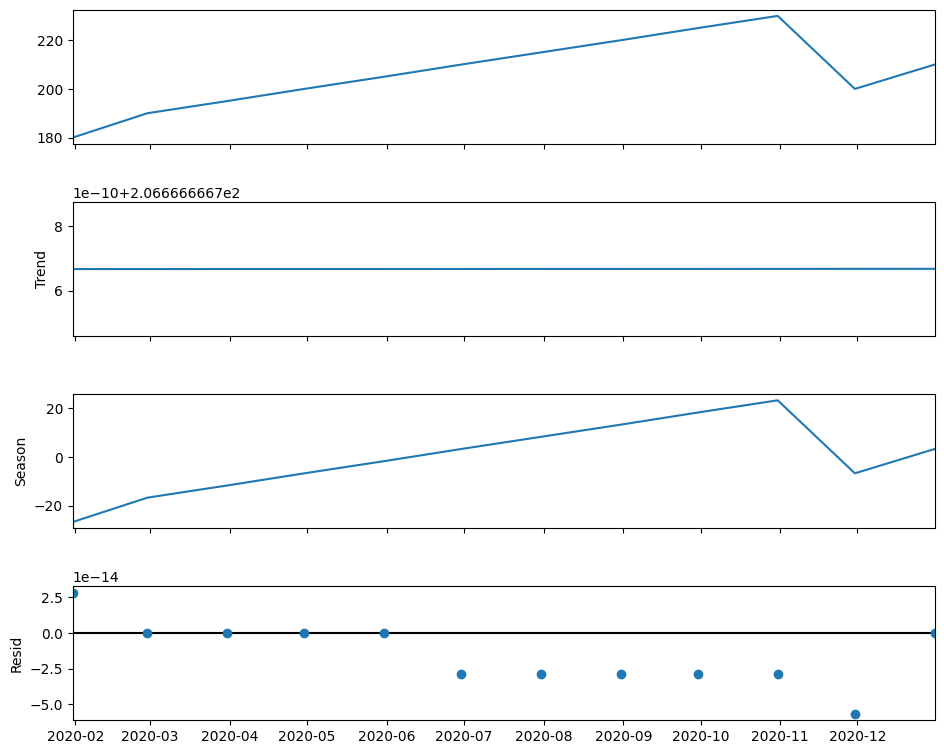

Trend forecast: [206.66666666666714, 206.6666666666672, 206.66666666666728]
Seasonal adjustments: [-26.66666667 -16.66666667 -11.66666667]
Total forecast: [180. 190. 195.]


In [16]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# Creating date range
dates = pd.date_range(start='2020-01-01', periods=12, freq='M')

# Creating synthetic data
sales = np.array([180, 190, 195, 200, 205, 210, 215, 220, 225, 230, 200, 210])

# Convert to pandas series
data = pd.Series(sales, index=dates)

# Apply STL decomposition with an odd seasonal length
stl = STL(data, seasonal=13, robust=True)  # Using 13 as the seasonal length for the example
result = stl.fit()

# Extract components
trend = result.trend
seasonal = result.seasonal
resid = result.resid

# Plotting the decomposition
fig = result.plot()
fig.set_size_inches((10, 8))
plt.show()

# Forecasting
forecast_period = 3
last_known_trend = trend.dropna().iloc[-1]
if len(trend.dropna()) > 1:  # Ensure there is enough data to calculate slope
    trend_slope = (trend.dropna().iloc[-1] - trend.dropna().iloc[0]) / (len(trend.dropna()) - 1)
else:
    trend_slope = 0  # Default to zero if not enough trend data

# Project the trend
trend_forecast = [last_known_trend + trend_slope * i for i in range(1, forecast_period + 1)]

# Assuming yearly seasonality, reuse the last known seasonal effects
seasonal_forecast = seasonal[-12:][:forecast_period].values

# Combine trend and seasonal forecasts
total_forecast = trend_forecast + seasonal_forecast

# Display forecast
print("Trend forecast:", trend_forecast)
print("Seasonal adjustments:", seasonal_forecast)
print("Total forecast:", total_forecast)


## Exponential Smoothing Models
- Forecasts are weighted averages of past observations with the weights decaying exponentially such that recent observations get weighted more than distant observations. 

**Types**
- Simple Exponential Smoothing
- Holt's Method
- Holt's Method with Damping
- Holt-Winter's Seasonal Method

**Additive and Multiplicative Method**
**State Space Models**

### Exponential Smoothing: Overview
**Underlying Thoery**
- Exponential Smoothing methods are time series forecasting techniques that apply smoothing factors to make forecasts. These methods weigh recent observations more heavily than older ones, using an exponential decay to assign decreasing weights over time.

**Simple Example of Exponential Smoothing:**
- Suppose you have monthly sales data: [200, 210, 220]. Using exponential smoothing to forecast the next month's sales might look like this:

* Assign a smoothing factor, 𝛼, such as 0.3.
* Start with an initial estimate, say the first data point (200).
* Update the forecast using Forecastnew=𝛼 × Observationnew + (1−𝛼) × Forecastold.

**Detailed Steps for Exponential Smoothing Calculation**

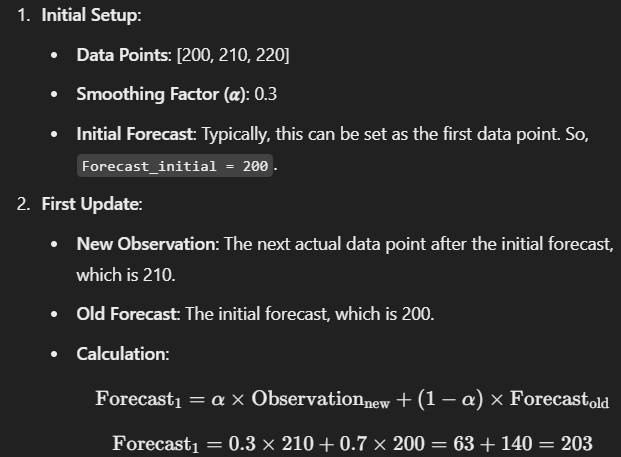

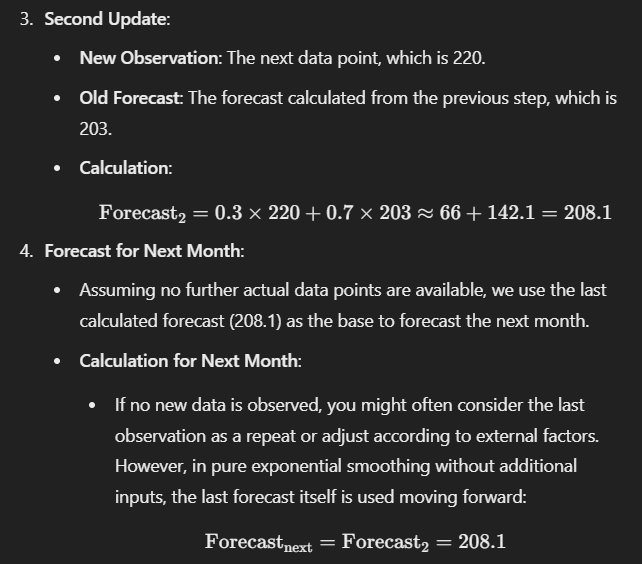

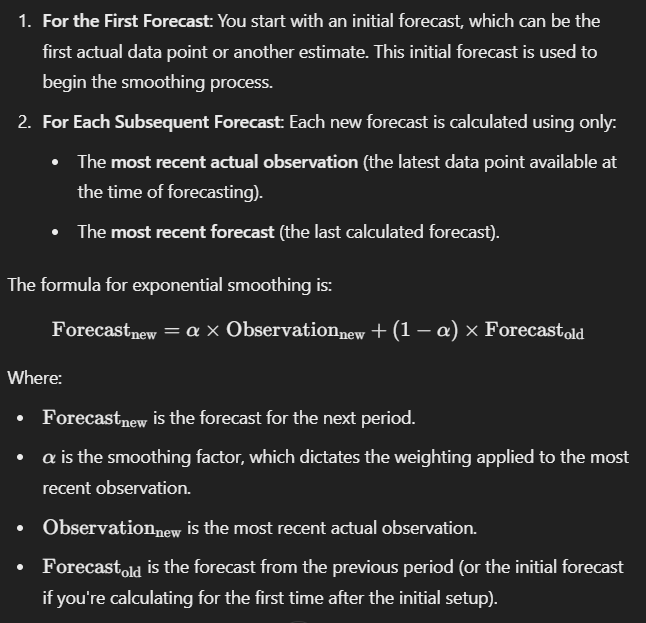

- This method assumes that each new forecast can be accurately estimated by appropriately balancing the latest actual data point and the previous forecast's momentum, which incorporates all the prior data indirectly through the exponential decay of influence.

In [18]:
# Exponential Smoothing Manual Calculation
data = [200, 210, 220]  # Monthly sales data
alpha = 0.3  # Smoothing factor

# Start with the first data point as the initial forecast
forecast = [data[0]]  # Initial forecast is the first data point

# Exponential smoothing calculations
for i in range(1, len(data)):
    new_forecast = alpha * data[i] + (1 - alpha) * forecast[-1]
    forecast.append(new_forecast)

# Output the forecasts
print("Forecasts:", forecast)
# Predicting the next month's sales based on the last forecast
next_month_forecast = forecast[-1]
print("Forecast for next month:", next_month_forecast)

Forecasts: [200, 203.0, 208.1]
Forecast for next month: 208.1


### Simple Exponential Smoothing
**Underlying Thoery**
- This method is suitable for forecasting data without any clear trend or seasonality. It assigns exponentially decreasing weights as observations get older, essentially giving greater importance to more recent observations.
- Forecasts are calculated using weighted averages, where the weights decrease exponentially. Most recent observations get the heaviest weight.

**Calculation**

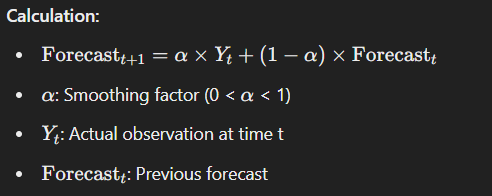

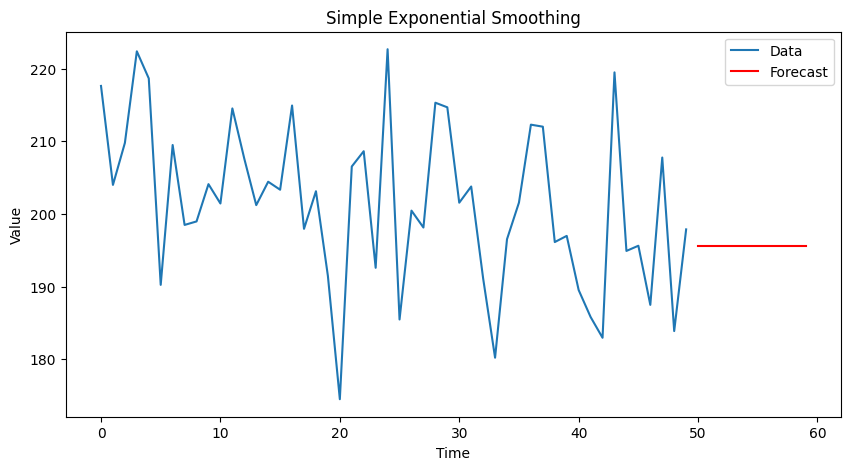

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Generate synthetic data
np.random.seed(0)
data = np.random.normal(loc=200, scale=10, size=50)

# Simple Exponential Smoothing
model = SimpleExpSmoothing(data)
fitted_model = model.fit(smoothing_level=0.2, optimized=False)

# Forecast
forecast = fitted_model.forecast(10)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(data, label='Data')
plt.plot(np.arange(len(data), len(data) + 10), forecast, label='Forecast', color='red')
plt.title('Simple Exponential Smoothing')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()


### Holt's Method (Holt's Linear Trend Method)
**Underlying Theory**
- Extends simple exponential smoothing by explicitly including support for trends in the data. It's suitable for data exhibiting a trend.

**Calculation**

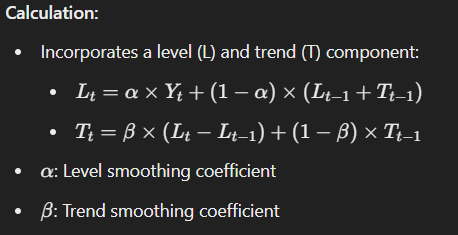

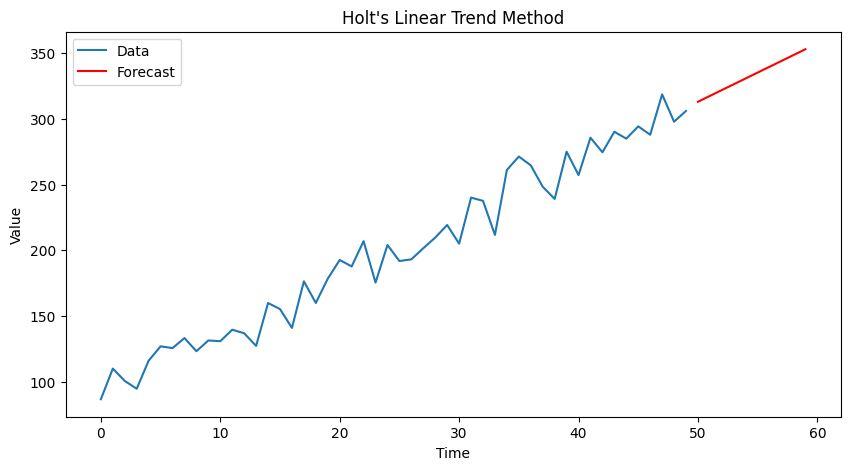

In [20]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Generate synthetic data with a trend
data = np.linspace(100, 300, 50) + np.random.normal(scale=15, size=50)

# Holt's linear trend model
model = ExponentialSmoothing(data, trend='add', seasonal=None)
fitted_model = model.fit()

# Forecast
forecast = fitted_model.forecast(10)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(data, label='Data')
plt.plot(np.arange(len(data), len(data) + 10), forecast, label='Forecast', color='red')
plt.title("Holt's Linear Trend Method")
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()


### Holt's Method with Damping
**Underlying Theory**
- This method adds a damping parameter to Holt’s linear method to prevent the trend component from becoming unrealistic in the long-term forecasts.

**Calculation**

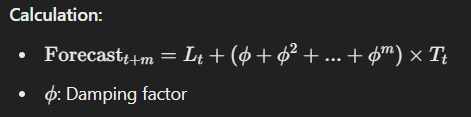


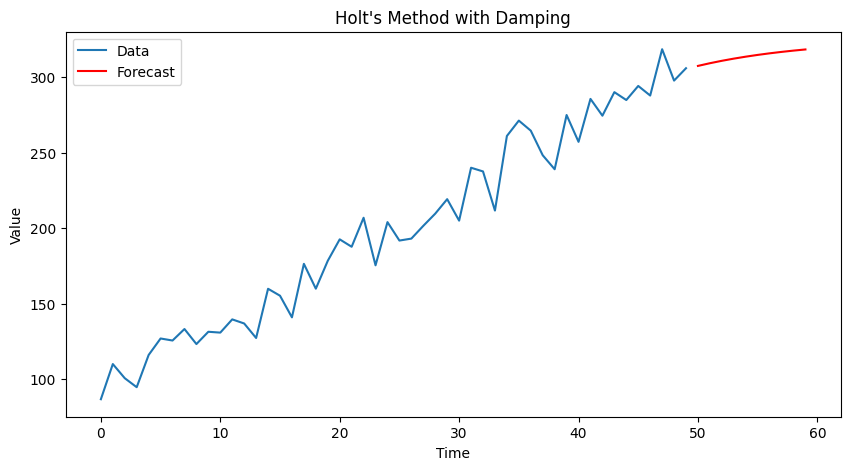

In [21]:
# Holt's method with damping
model = ExponentialSmoothing(data, trend='add', seasonal=None, damped_trend=True)
fitted_model = model.fit(smoothing_level=0.8, smoothing_trend=0.2, damping_trend=0.9)

# Forecast
forecast = fitted_model.forecast(10)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(data, label='Data')
plt.plot(np.arange(len(data), len(data) + 10), forecast, label='Forecast', color='red')
plt.title("Holt's Method with Damping")
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

### Holt-Winter's Seasonal Method
**Underlying Theory**
- Incorporates level, trend, and seasonal components, each with its own smoothing coefficient. It’s ideal for data with both trend and seasonality.

**Calculation**

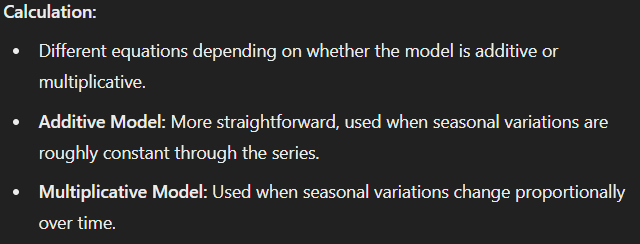

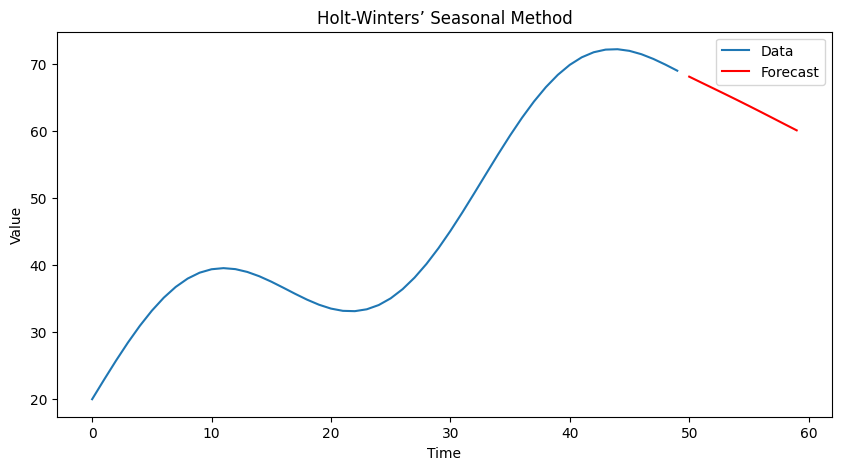

In [22]:
# Generate seasonal data
data = 20 + np.arange(50) + 10 * np.sin(np.linspace(0, 3 * np.pi, 50))

# Holt-Winters model
model = ExponentialSmoothing(data, trend='add', seasonal='add', seasonal_periods=10)
fitted_model = model.fit()

# Forecast
forecast = fitted_model.forecast(10)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(data, label='Data')
plt.plot(np.arange(len(data), len(data) + 10), forecast, label='Forecast', color='red')
plt.title("Holt-Winters’ Seasonal Method")
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

### Additive vs. Multiplicative:
* Additive Method: Used when the seasonal effect is constant and does not vary with the level of the time series.
* Multiplicative Method: Used when the seasonal effect varies proportionally to the level of the time series.

**Benefits and Drawbacks:**
* Additive:
    - Pros: Simpler to understand and apply; good for data with stable seasonality.
    - Cons: Can be inadequate for data where seasonal effects intensifying over time.
* Multiplicative:
    - Pros: Handles increasing or decreasing seasonal patterns; more flexible for complex data.
    - Cons: More complex to implement and interpret; can amplify noise in data.

**Additive Seasonality**
* Definition: In additive seasonality, the seasonal effect is constant across the series. This means that the magnitude of the seasonal fluctuations is the same regardless of the level of the time series.

* Example
- Example with Numbers: Suppose you have a monthly sales series where the base sales are increasing, but the seasonal effect—due to an event like Black Friday—adds a constant boost of 100 units in November every year.
    * January Sales: 500
    * February Sales: 520
    * ...
    * November Sales (base + seasonal effect): 600 (base) + 100 (seasonal effect) = 700
    * December Sales: 620
- Regardless of the underlying trend, the seasonal boost in November is always +100 units.

* Real-World Example: A bookstore sells more books during the start of the academic year each September. The increase in sales due to the season is constant, say 300 more books, whether the store sells 1,000 or 5,000 books in other months.

**Multiplicative Seasonality**
* Definition: In multiplicative seasonality, the seasonal effect varies in proportion to the level of the time series. This means that the size of the seasonal effect grows or shrinks with the data, which is often more realistic for economic and financial series where growth rates are important.

* Example
E- xample with Numbers: Let’s say you’re analyzing the monthly sales data of a beach resort, which sees a seasonal increase in the summer months that is proportional to the sales level.
    * January Sales: 100
    * June Sales: 300
    * July Sales (base * seasonal factor): 300 * 1.5 = 450
- Here, the seasonal factor for July is 1.5, meaning sales are 50% higher than typical sales in that month. The impact of seasonality grows as the base sales level increases.

* Real-World Example: Electricity consumption varies throughout the year. In hot months, the consumption increases significantly due to air conditioning. The higher the base usage, the more significant the increase in percentage terms. If a factory uses 10,000 kWh in cooler months, it might use 15,000 kWh in hot months (a 50% increase), while a small shop using 500 kWh might increase to 650 kWh (a 30% increase).

### State Space Models (SSM)
- The concept of State Space Models (SSM) in time series analysis involves using mathematical models to represent physical, social, economic, or other phenomena. These models are particularly powerful for understanding and predicting time series data. 

**Components of State Space Models:**
1. Measurement Equation: This equation relates the observed data to the underlying state of the system. It describes how each observation in the time series is generated from the hidden states.

2. State Equations: These equations describe how the underlying states (such as the level, trend, and seasonal components of the series) evolve over time. These states are not directly observable; they are inferred from the data.

**Why Use State Space Models?**
* They provide a flexible framework for modeling time series data, allowing for the inclusion of components like trends and seasonality.
* They can handle irregular time series and missing data efficiently.
* They allow for dynamic updates to the forecasts as new data becomes available.

**Example Explained:**
- Suppose we're modeling the monthly sales of a retail store. In this context:
    * Level: This represents the baseline value of the sales, which might change slowly over time.
    * Trend: This is the direction in which the sales are moving month over month. For example, sales could be increasing due to seasonal effects.
    * Seasonal: This captures regular patterns that repeat at known intervals, such as higher sales in December due to the holiday season.

**Simple Numeric Example:**
- Let’s say you have the following monthly sales data (in thousands): [10, 12, 15, 20, 18]. You want to model this data using a state space approach.
    * Level (L) might start at 10 (the first sales data point).
    * Trend (T) might initially be estimated as the difference between the first two points, say 2.
    * Seasonal (S) adjustments might be calculated from the data but let's assume initially it's just the deviation from the level and trend.

- Updating with New Data:
- When the next data point (15) is observed:
    * New Level: Might be a weighted average of the predicted level (previous level + trend) and the actual sales.
    * New Trend: Updated by comparing the change in level to the previous trend.
    * Seasonal Component: Adjusted to account for any repetitive patterns that don't fit the level or trend.
- These updates continue as more data becomes available, refining the model's estimates of the level, trend, and seasonal components.

**State Space Equations:**
* For an additive model:
    - Measurement Equation: 𝑦𝑡 = 𝐿𝑡 − 1 +𝑇𝑡−1 + 𝑆𝑡−𝑚 + 𝜖𝑡 
    - 𝑦𝑡 is the sales at time t.
    - 𝐿𝑡−1 is the level at time t-1.
    - 𝑇𝑡−1 is the trend at time t-1.
    - 𝑆𝑡−𝑚 is the seasonal component from m periods ago (e.g., if m=12 for monthly data with yearly seasonality).
    - 𝜖𝑡 is the error term at time t.
- State Equations: Update rules for 𝐿𝑡, 𝑇𝑡, and 𝑆𝑡 based on the model parameters and new observations.

- By continuously updating these estimates, the state space model provides a dynamic way to forecast future sales while adjusting to changes in trends and seasonal patterns. This approach is powerful in forecasting and analyzing time series where multiple influencing factors change over time.

## ARIMA (AutoRegressive Integrated Moving Average)
- Exponential Smoothing and ARIMA are the two most widely used approaches to time-series forecasting and provide complementary approaches to the problem.
- While ***Exponential Smoothing models are based on a description of trend and seasonality in the data***, ***ARIMA models aim to describe autocorrelations in the data***

**What is ARIMA?**
- ARIMA stands for AutoRegressive Integrated Moving Average. It is a class of models that explains a given time series based on its own past values, namely its lags and the lagged forecast errors, so that equation can be used to forecast future values.
    * AR (AutoRegressive): Refers to the use of past values in the regression equation for the time series.

    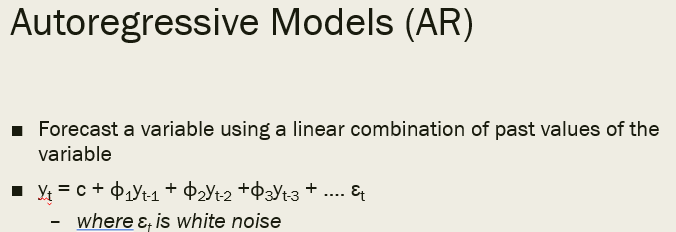

    * I (Integrated): Represents the differencing of raw observations to make the time series stationary, which means that the series has constant mean and variance over time and doesn't exhibit trends or seasonality.
    * MA (Moving Average): Incorporates the dependency between an observation and a residual error from a moving average model applied to lagged observations.

    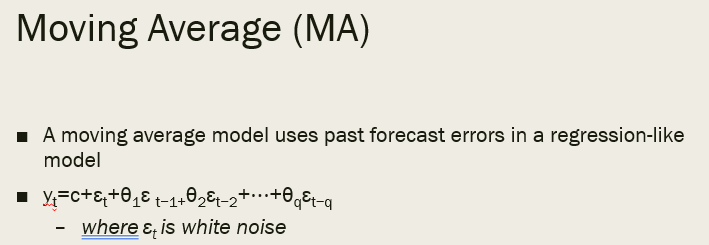

- ARIMA: Uses a structured model based on stochastic processes defined by parameters with statistical significance. It models the correlations in the data.

**Data Requirements:**
* ARIMA: Requires the data to be stationary. Non-stationary data must be differenced to achieve stationarity before applying ARIMA.
* ARIMA: More flexible in handling a wide range of different time series patterns but is more complex to configure correctly because it requires choosing p, d, and q parameters.

**Predictive Components:**
- ARIMA: Explicitly models the error terms and can include additional terms for past errors (MA component).

**Simple Example of ARIMA**
- Suppose you have monthly sales data and you want to forecast the next month's sales. Here's a simplified overview of how you might approach building an ARIMA model:
- Data: [200, 210, 215, 220, 225, 230, 235, 240]

* Stationarity: First, check if the data is stationary. This might involve differencing the data, for example:
* Differenced Data: [10, 5, 5, 5, 5, 5, 5]
* Model Identification: Choose the ARIMA parameters:
    - p (lags of the autoregressive term)
    - d (degree of differencing)
    - q (lags of the moving average term)
* For simplicity, suppose p=1, d=1, q=1.

* Model Fitting:
    - Fit the ARIMA(1,1,1) model to the differenced data.
* Forecasting:
    - Use the model to forecast the next point in the series.

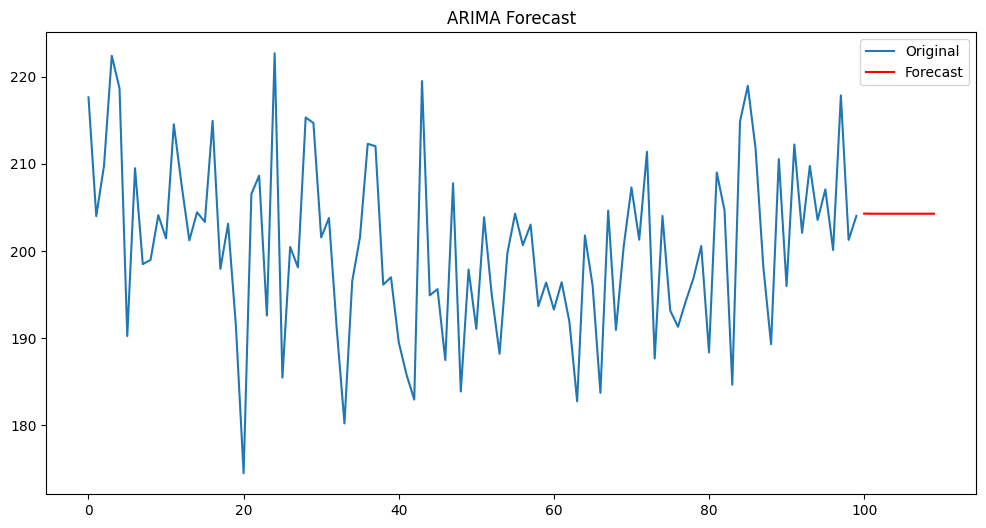

In [23]:
# Code Example of Simple ARIMA Model
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
data = np.random.normal(200, 10, 100)  # Synthetic daily sales data

# Fit ARIMA model
model = ARIMA(data, order=(1,1,1))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=10)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(data, label='Original')
plt.plot(np.arange(len(data), len(data) + 10), forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast')
plt.legend()
plt.show()

### Making Time Series Stationary
- Integration (I) in ARIMA: Integration in the context of ARIMA refers to the differencing of consecutive observations to make a time series stationary. A stationary time series is one whose statistical properties such as mean, variance, and autocorrelation are all constant over time.

**Why Stationarity Matters:**
- Most time series models, including ARIMA, assume that the underlying data does not change its behavior over time, making the model's mathematics valid for forecasting. If a time series exhibits trends (increasing or decreasing over time) or seasonality (patterns that repeat over a fixed period), it can lead to biased or misleading results when used with models that assume stationarity.

**How Differencing Works**
- Differencing is a transformation applied to the original time series data. If your time series data 𝑌𝑡 shows trends or seasonality, you calculate the difference between each pair of consecutive observations. This is often enough to remove these components, resulting in a stationary series:

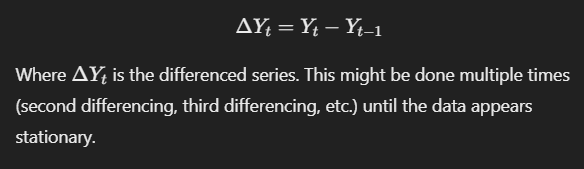

### Moving Average (MA)
- Moving Average in ARIMA: The moving average component in an ARIMA model is a way to account for changes in the series that are not explained by the trend and seasonal components alone. It models the error terms (residuals) as a linear combination of the error terms of the previous time points.
- Understanding MA: When you use a moving average model, you're saying that the current value of your series is a function of the average of the previous data points' errors plus a noise term. This helps to smooth out random fluctuations and identify underlying patterns.

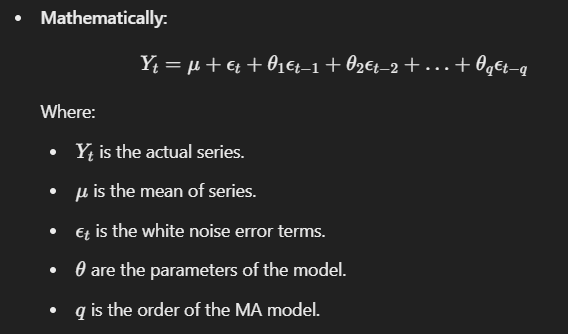

### How Stationarity Relates to Trend and Seasonality in Forecasting
- When you make a time series stationary and use an ARIMA model for forecasting:
    * For Trend: You model and predict the changes (differences) rather than the absolute values. When you forecast future values, you typically have to "integrate" these predictions back by adding them to the original data's last known value or trend line to get actual forecasts.
    * For Seasonality: Standard ARIMA models do not handle seasonality. This is why the Seasonal ARIMA (SARIMA) model exists, which extends ARIMA by adding seasonal differencing, which is like regular differencing but involves lagging over the period (e.g., subtracting the value from last year if your data is monthly and has yearly seasonality).

- This approach of differencing, then forecasting, then "integrating" (cumulatively adding the forecasts to past real data to make predictions for future levels) allows the ARIMA model to forecast data that might still technically have trends and seasonality but treats these aspects through the differencing process rather than modeling them directly in their raw form. This technique is particularly useful because it simplifies the model while allowing it to make effective forecasts.

### Stationary Process (Unit Root Tests & Stabilization Transformation Methods)
**Stationary Process:**
- A stationary time series is one whose properties do not depend on the time at which the series is observed. This means:
    * Constant mean: The average value of the series does not change over time.
    * Constant variance: The variability of the series remains constant over time.
    * Constant autocovariance: How the values of the series at different times covary remains consistent over time.
**Unit Root Tests:**
- Unit root tests are statistical tests used to determine if a time series is non-stationary and possesses a unit root, which means that it shows some form of persistent, stochastic trend.

**Example of a Unit Root Test: KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin)**
* Purpose: To test the null hypothesis that a time series is stationary around a deterministic trend (i.e., the series is trend-stationary).
* Calculation: KPSS tests the stationarity of a time series by decomposing the series into:
    - deterministic trend (systematic component that doesn’t change randomly).
    - A stochastic trend (random component that can cause random shifts in the level of the series).
    - A stationary error term.

**Stabilization Transformation Methods**
1. Box-Cox Transformation
- A Box-Cox transformation is a way to stabilize variance and make a dataset more closely conform to a normal distribution.
    * Purpose: To transform non-normal dependent variables into a normal shape.
    * Calculation

    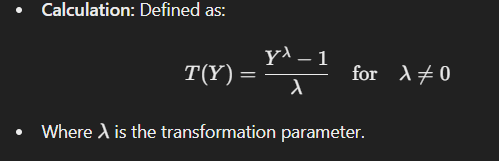

2. Differencing
- Differencing is a method of transforming a time series dataset.
    * Purpose: To remove the series' dependence on time, such as trends and seasonality
    * Calculation

    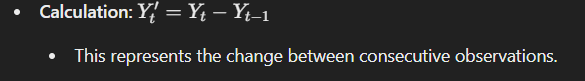

In [30]:
# Function to perform KPSS Test
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import kpss

# Generate synthetic data
np.random.seed(0)
data = np.random.normal(loc=0, scale=1, size=100).cumsum()

# KPSS Test
statistic, p_value, lags, critical_values = kpss(data, regression='c')

print("KPSS Statistic:", statistic)
print("P-Value:", p_value)
print("Critical Values:", critical_values)

KPSS Statistic: 1.1001161286471663
P-Value: 0.01
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\Michael\AppData\Local\Temp\ipykernel_42020\1175557901.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, lags, critical_values = kpss(data, regression='c')


* KPSS Statistic: The test statistic is a value calculated based on the series being tested. For your data, the KPSS statistic is 1.1001161286471663. The higher this value, the stronger the evidence against the null hypothesis that the series is stationary.

* P-Value: The p-value is used to decide whether to reject or fail to reject the null hypothesis. In the context of the KPSS test, the null hypothesis states that the series is stationary. A low p-value (typically less than 0.05) indicates strong evidence against the null hypothesis, suggesting that the series is not stationary. Your p-value of 0.01 suggests that the series is likely non-stationary.

* Critical Values: These values correspond to different significance levels for the test. They are used to determine the critical decision point at which the null hypothesis can be rejected. The values provided are:
    - 10%: 0.347
    - 5%: 0.463
    - 2.5%: 0.574
    - 1%: 0.739
* You compare the KPSS statistic to these critical values:
    - If the KPSS statistic is greater than the critical value at a certain significance level, you reject the null hypothesis at that level.
    - Given your KPSS statistic of 1.100, it is higher than all the critical values listed, which means you can reject the null hypothesis of stationarity at the 1% level (strong evidence that the series is non-stationary).

In [25]:
# Code Example for Boc-Cox Transformation
from scipy.stats import boxcox

# Generating data
data = np.random.exponential(size=100)  # Non-normal data

# Apply Box-Cox Transformation
transformed_data, best_lambda = boxcox(data)

print("Transformed Data:", transformed_data)
print("Lambda:", best_lambda)

Transformed Data: [-0.55072432 -0.06934527 -2.44657753 -0.89731664  0.07710857 -0.93258591
 -0.03815682 -0.53753274 -1.50911887 -0.90735274 -0.16597452 -0.11069665
 -0.15447999  0.05777167  0.05473893 -0.53043389  0.91488275 -0.7050851
 -0.51854365  0.89076823  0.5292078   0.20160541 -1.69373921  1.0469086
  0.23208395  2.48935051 -1.44453707  0.77637757 -1.3875643  -0.04476488
 -1.56629106  0.68960894  0.53324781 -0.16825078 -0.59577499 -1.89679284
  0.18280251 -0.47152036  0.25539162  0.76854092  1.56756878  0.72232751
 -2.61052659 -0.72644624  0.27934669 -1.34930726 -0.29424285 -2.01670112
 -1.23773507 -2.45916108  0.48516689 -1.15052487 -0.76811781  1.10325374
  0.20314299 -2.25347574 -1.37823044 -0.02882177 -0.14681731 -1.10198152
  1.14647936 -0.04904762 -0.2560634  -0.11325197  0.27974614 -0.86602377
 -0.62020104 -1.20117151 -1.29077617  1.22507929  0.30862328 -0.3742766
 -1.13824606 -1.04667249 -1.98491395 -0.52241352 -0.86647044  0.17965887
 -0.6766243  -1.31690898 -2.35410079

### Non-Seasonal ARIMA

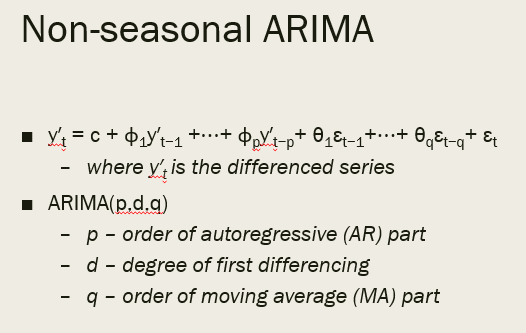

- The non-seasonal ARIMA model is a widely used tool for time series forecasting. It combines autoregressive features, integration (differencing), and moving average components to model time series data that exhibits non-seasonal patterns. Here’s a breakdown of the components:
    * AR (Autoregressive): This part involves using past values of the series to predict the future. It is specified by the parameter p, which represents the number of lag observations included in the model.
    * I (Integrated): This component involves differencing the time series to make it stationary (i.e., to remove trends and seasonality). The parameter d specifies the number of times the data need to be differenced to achieve stationarity.
    * MA (Moving Average): This part models the error term as a linear combination of error terms that occurred contemporaneously and at various times in the past. The parameter q specifies the number of lagged forecast errors in the prediction equation.

**ARIMA Equation:**

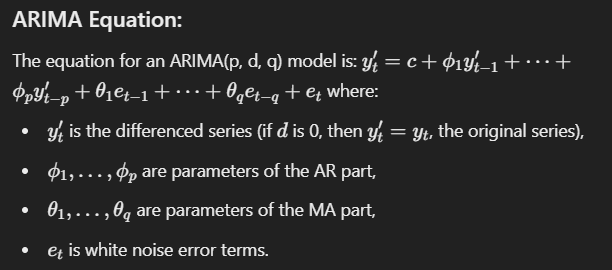


c:\Users\Michael\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


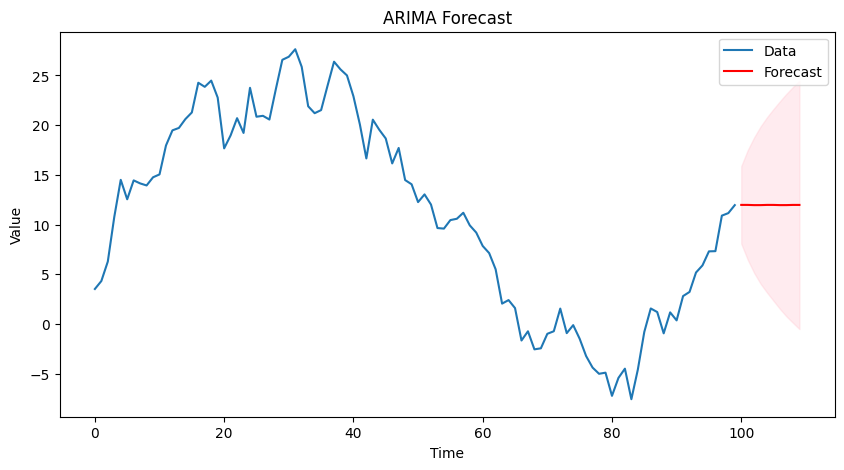

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Generate synthetic data
np.random.seed(0)
n = 100
data = np.cumsum(np.random.normal(0, 2, n))  # Cumulative sum to simulate non-stationary data

# Fit an ARIMA model
model = ARIMA(data, order=(2, 1, 2))  # ARIMA(2,1,2)
fitted_model = model.fit()

# Forecast
forecast_result = fitted_model.get_forecast(steps=10)  # Get forecast results
forecast = forecast_result.predicted_mean  # Forecasted values
stderr = forecast_result.se_mean  # Standard errors of forecasts
conf_int = forecast_result.conf_int(alpha=0.05)  # 95% confidence intervals

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(data, label='Data')
plt.plot(np.arange(n, n + 10), forecast, label='Forecast', color='red')
plt.fill_between(np.arange(n, n + 10), conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)
plt.title('ARIMA Forecast')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

### Seasonal ARIMA

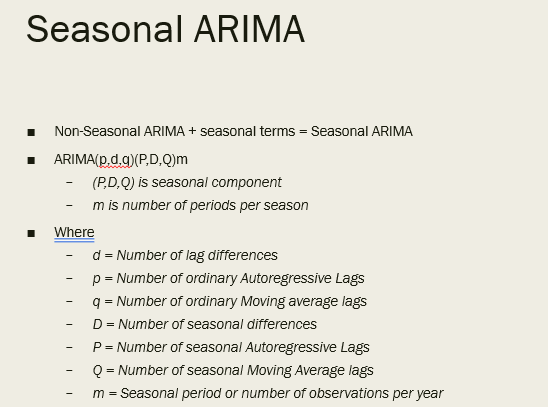

- Seasonal ARIMA (SARIMA) models are an extension of ARIMA models that specifically address seasonality in time series data. They are useful for series where data exhibit repeating patterns at consistent intervals, such as daily temperatures, monthly sales, or quarterly economic data.

**Underlying Theory**
- A Seasonal ARIMA model incorporates both non-seasonal and seasonal factors in a multiplicative model:
* ARIMA(p, d, q): The non-seasonal part of the model, which includes:
    - p: Number of autoregressive terms (AR lags)
    - d: Number of differences required to make the series stationary
    - q: Number of moving-average terms (MA lags)

* ARIMA(P, D, Q)m: The seasonal part of the model, which includes:
    - P: Number of seasonal autoregressive terms
    - D: Number of seasonal differences required to stationarize the series
    - Q: Number of seasonal moving-average terms
    - m: Number of periods in each season

**Calculation**

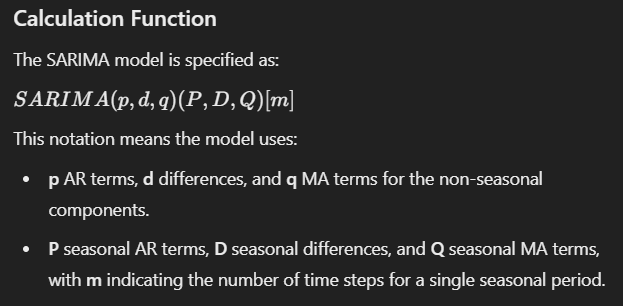



C:\Users\Michael\AppData\Local\Temp\ipykernel_42020\3052444401.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2020-01-01', periods=n_points, freq='M')
c:\Users\Michael\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


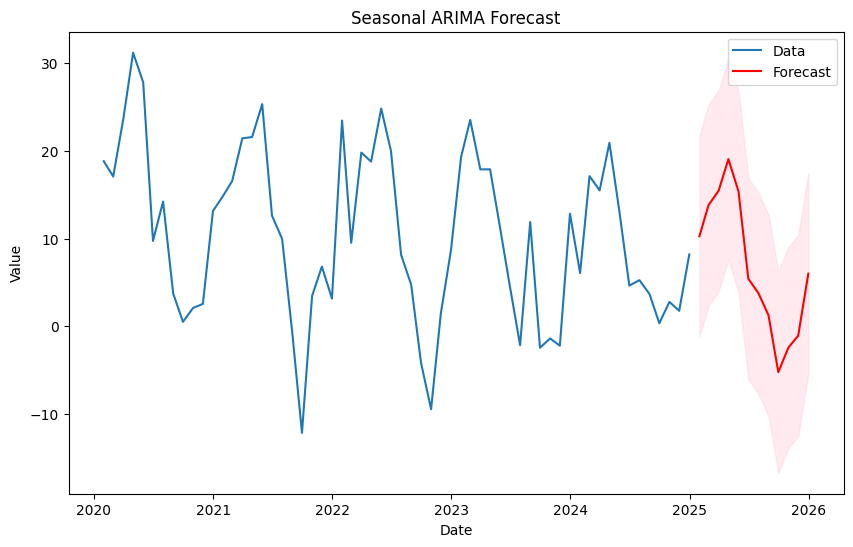

In [33]:
# Code Example for Seasonal ARIMA
# The seasonality pattern repeats every year (12 months) 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Generate synthetic seasonal data
np.random.seed(0)
n_years = 5
n_points = n_years * 12
data = 10 + (np.sin(np.linspace(0, n_years * 2 * np.pi, n_points)) + np.random.normal(scale=0.5, size=n_points)) * 10

# Convert to pandas series
dates = pd.date_range(start='2020-01-01', periods=n_points, freq='M')
data_series = pd.Series(data, index=dates)

# Fit a Seasonal ARIMA model
model = SARIMAX(data_series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
fitted_model = model.fit(disp=False)

# Forecast
forecast = fitted_model.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(data_series, label='Data')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_conf_int.index, forecast_conf_int.iloc[:, 0], forecast_conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('Seasonal ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

### Determining Parameters for ARIMA Model
- Determining the correct parameters for an ARIMA model, specifically the levels of differencing (d), autoregression (p), and moving average (q), typically involves a combination of statistical tests and graphical analysis. Here are the general steps you can follow to identify these parameters:

1. Differencing (d)
- Objective: Ensure the time series is stationary.
**Steps:**
* Plot the Time Series: Look for obvious trends or seasonality.
* Unit Root Tests: Perform tests like the Augmented Dickey-Fuller (ADF) test or KPSS test to statistically confirm if the series is non-stationary.
* Differencing: Apply first differencing to the series and retest for stationarity. Repeat if necessary. The minimum number of differencing needed to achieve stationarity is your d value.
2. Autoregressive Order (p)
- Objective: Determine how many past values the model should use to predict the future.
**Steps:**
* Partial Autocorrelation Function (PACF): After making the series stationary, plot the PACF. Look for a sharp cut-off or significant lags; the number of significant lags before the cut-off point generally gives the order of the AR term (p).
3. Moving Average Order (q)
- Objective: Model the error of the lagged predictions.
**Steps:**
* Autocorrelation Function (ACF): For a stationary series, plot the ACF to identify the moving average component. Like PACF for AR, the number of significant lags in the ACF plot before it cuts off is the MA term (q).

**Interpretation:**
- ADF Test: If the p-value is less than 0.05, the series can be considered stationary. If not, differencing may be required.
- PACF & ACF Plots: These will guide the selection of p and q. For instance, if PACF shows significant values at the first two lags and then cuts off, set p=2. If ACF shows a slow decay, this might suggest the need for an MA component.

ADF Statistic: -1.3583317659818985
p-value: 0.6020814791099101
ADF Statistic after differencing: -10.008881137130237
p-value after differencing: 1.800687720719554e-17


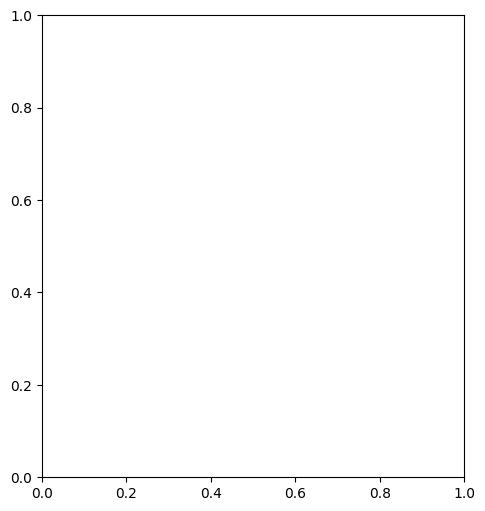

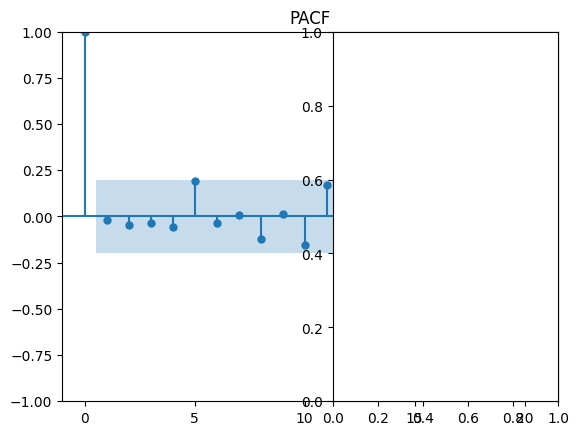

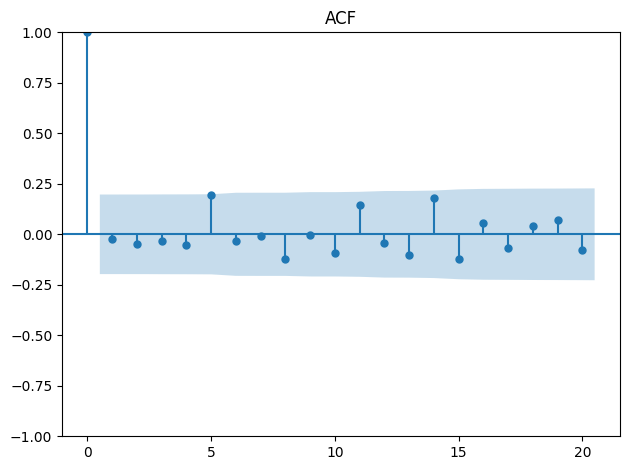

In [34]:
# Code Example of the Steps for Parameters Selection
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss, pacf, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Generate synthetic data
np.random.seed(42)
data = np.cumsum(np.random.normal(0, 1, 100))  # Non-stationary data

# Check for stationarity
adf_result = adfuller(data)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

# Differencing
diff_data = np.diff(data, n=1)

# Re-check stationarity
adf_result_diff = adfuller(diff_data)
print("ADF Statistic after differencing:", adf_result_diff[0])
print("p-value after differencing:", adf_result_diff[1])

# Plot PACF and ACF
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_pacf(diff_data, lags=20, method='ywm')
plt.title('PACF')

plt.subplot(122)
plot_acf(diff_data, lags=20)
plt.title('ACF')
plt.tight_layout()
plt.show()

## Advanced Time Series Models
* Hierarchical and Grouped Time Series
* Neural Network Autoregression

### Hierarchical and Grouped Time Series
- What It Is: Hierarchical and grouped time series involve structuring multiple related time series within a hierarchy or grouping them based on certain criteria. This method is often used in forecasting problems where data can naturally be divided into subgroups that roll up into higher levels of aggregation.

- Underlying Theory: The main concept is to exploit the hierarchical structure within the data to improve forecast accuracy across the hierarchy. Forecasts are generated for each level of the hierarchy and then reconciled to ensure that they are consistent across levels. This approach can help in leveraging both the granular and aggregated data to produce more accurate and coherent forecasts.

- Calculation Function: Forecasts at lower levels are aggregated to produce forecasts at higher levels. Conversely, forecasts at higher levels can be disaggregated to inform forecasts at lower levels. Reconciliation methods, like the bottom-up approach or optimal reconciliation using least squares, ensure that forecasts are consistent across the hierarchy.

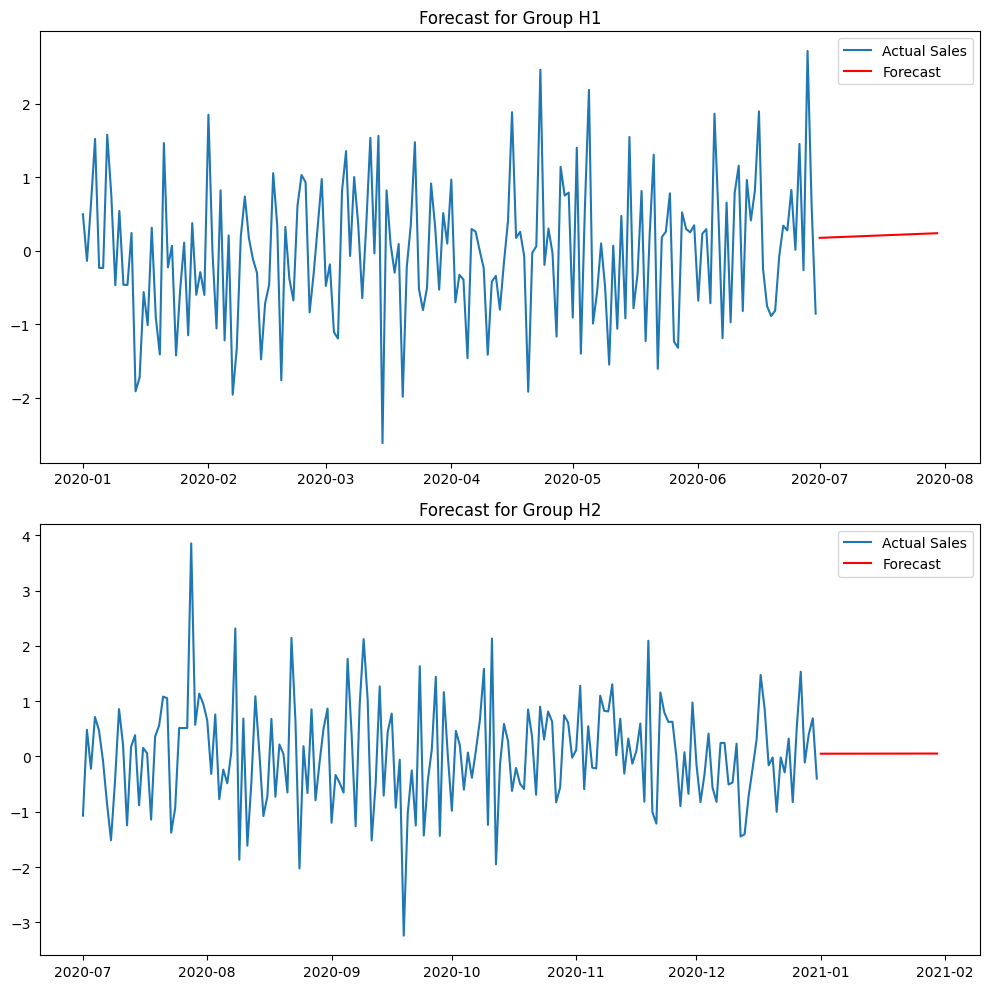

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Generating synthetic data
np.random.seed(42)
date_rng = pd.date_range(start='2020-01-01', end='2020-12-31', freq='D')
data = pd.DataFrame(np.random.randn(len(date_rng)), index=date_rng, columns=['sales'])
data['group'] = np.where(data.index.month <= 6, 'H1', 'H2')

# Forecast for each subgroup and plot results
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

for i, (group, group_data) in enumerate(data.groupby('group')):
    model = ExponentialSmoothing(group_data['sales'], trend='add', seasonal=None)
    fit = model.fit()
    forecast = fit.forecast(steps=30)  # Forecasting additional 30 steps

    # Plotting
    axs[i].plot(group_data['sales'], label='Actual Sales')
    axs[i].plot(pd.date_range(start=group_data.index[-1], periods=31, freq='D')[1:], forecast, label='Forecast', color='red')
    axs[i].set_title(f'Forecast for Group {group}')
    axs[i].legend()

plt.tight_layout()
plt.show()

### Neural Network Autoregression
* What It Is: Neural network autoregression (NNAR) combines the concepts of neural networks with autoregressive models. It is used to model complex nonlinear relationships in time series data.

* Underlying Theory: In NNAR, the past values of the time series are used as inputs to a neural network to predict future values. The neural network can capture nonlinear relationships and interactions between lagged terms that traditional linear models might miss.

* Calculation Function: NNAR models often use a feed-forward neural network where lagged observations are inputs, and the output is the future value of the series. Training involves minimizing a loss function, typically mean squared error, between the predicted and actual values.

4/4 [==============================] - 0s 855us/step


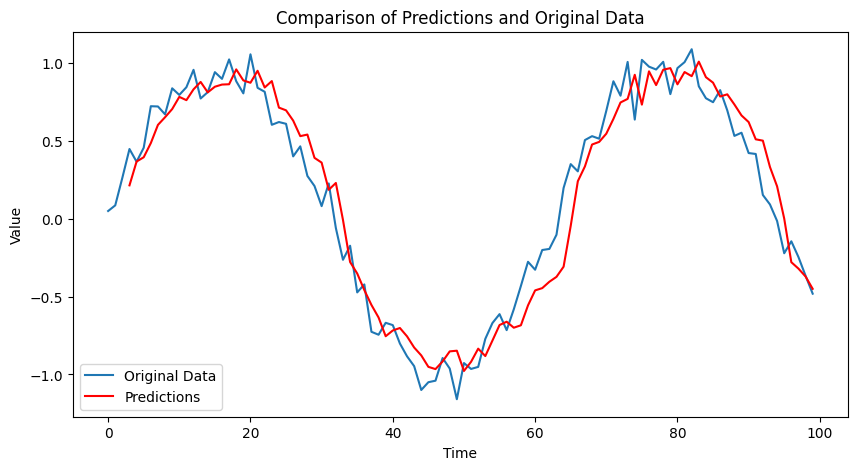

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense

# Generate synthetic data
np.random.seed(42)
data = np.sin(np.arange(100) * 0.1) + np.random.normal(scale=0.1, size=100)

# Prepare data
X = np.array([data[i:i+3] for i in range(len(data)-3)])
y = data[3:]

# Build model
model = Sequential([
    Dense(10, activation='relu', input_dim=3),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
model.fit(X, y, epochs=200, verbose=0)

# Generate predictions for all data points
predictions = model.predict(X)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(data, label='Original Data')
plt.plot(np.arange(3, 100), predictions.flatten(), 'r', label='Predictions')
plt.title('Comparison of Predictions and Original Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()